<a href="https://colab.research.google.com/github/geetanshu06/customer-purchase-prediction/blob/main/notebook/customer_purchase_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project: Predicting Future Customer Purchases

## Research Question

Can a user’s historical purchase behavior be used to predict whether they are likely to make a purchase in the next 30 days?

# This analysis uses transactional e-commerce data to perform exploratory data analysis (EDA), feature engineering, and build a baseline classification model.

# **1. Data Acquisition**

In [23]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use("seaborn-v0_8")

**Download Dataset Directly**

In [24]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


**2. Initial Exploration**

In [25]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


**3. Data Cleaning**


In [26]:
#Remove Missing Customer IDs
df = df.dropna(subset=["CustomerID"])

#Remove Duplicates
df = df.drop_duplicates()

#Remove Returns / Negative Values

df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]



**4. Feature Engineering**


In [27]:
#Create Total Price
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

#Convert Invoice Date
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])



**5. Create Time-Based Target (Realistic Classification)**


In [28]:
#If customer made a purchase in the last 30 days of dataset → 1 ,Else → 0
last_date = df["InvoiceDate"].max()
cutoff_date = last_date - pd.Timedelta(days=30)

recent_customers = df[df["InvoiceDate"] >= cutoff_date]["CustomerID"].unique()

**Aggregate to Customer Level**

In [29]:
customer_df = df.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "TotalPrice": "sum",
    "InvoiceDate": "max"
}).reset_index()

customer_df.columns = [
    "CustomerID",
    "TotalTransactions",
    "TotalQuantity",
    "TotalSpending",
    "LastPurchaseDate"
]

**Create Target Variable**

In [30]:
customer_df["Will_Purchase_30Days"] = np.where(
    customer_df["CustomerID"].isin(recent_customers), 1, 0
)

**6. Exploratory Data Analysis (EDA)**


**Spending Distribution**

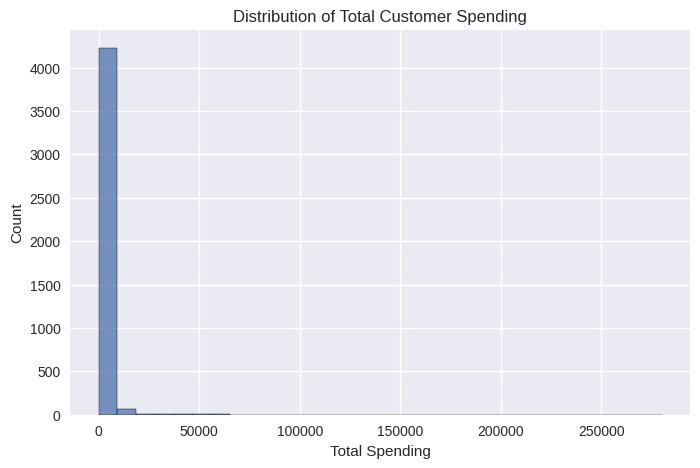

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(customer_df["TotalSpending"], bins=30)
plt.title("Distribution of Total Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Count")
plt.show()

**Transactions vs Spending**

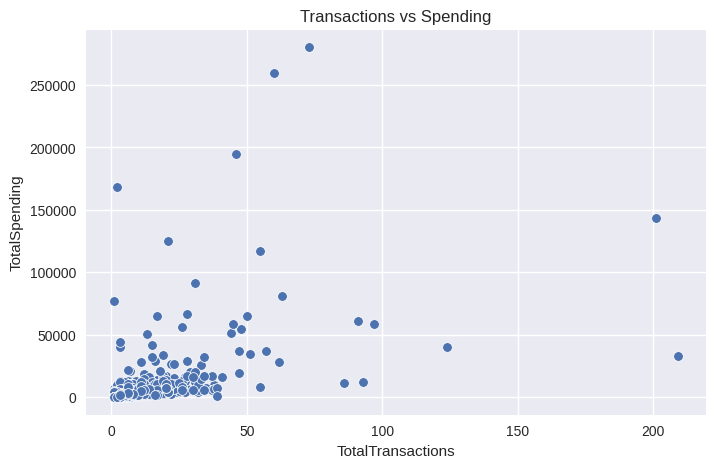

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="TotalTransactions",
    y="TotalSpending",
    data=customer_df
)
plt.title("Transactions vs Spending")
plt.show()

**Target Variable Balance**

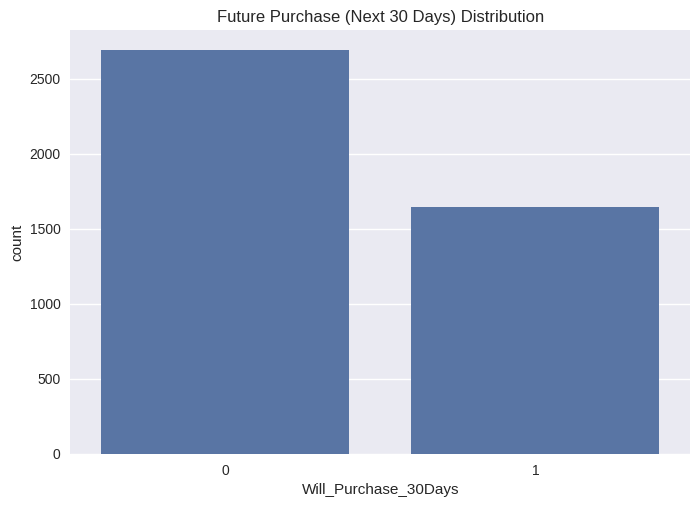

In [33]:
sns.countplot(x="Will_Purchase_30Days", data=customer_df)
plt.title("Future Purchase (Next 30 Days) Distribution")
plt.show()

**Correlation Heatmap**

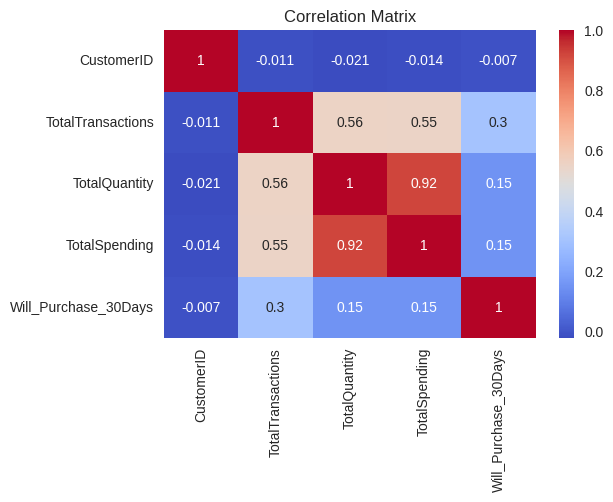

In [34]:
plt.figure(figsize=(6,4))
sns.heatmap(customer_df.corr(numeric_only=True),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**7. Outlier Analysis**

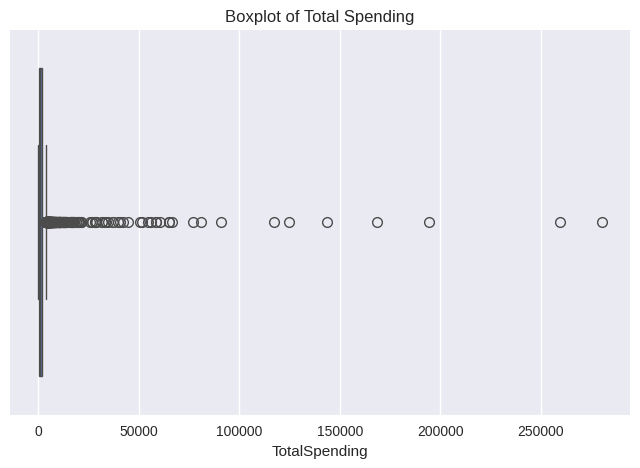

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x=customer_df["TotalSpending"])
plt.title("Boxplot of Total Spending")
plt.show()

In [36]:
Q1 = customer_df["TotalSpending"].quantile(0.25)
Q3 = customer_df["TotalSpending"].quantile(0.75)
IQR = Q3 - Q1

customer_df = customer_df[
    (customer_df["TotalSpending"] >= Q1 - 1.5 * IQR) &
    (customer_df["TotalSpending"] <= Q3 + 1.5 * IQR)
]

**8. Baseline Classification Model**

**Define Features & Target**

In [37]:
X = customer_df[["TotalTransactions", "TotalQuantity", "TotalSpending"]]
y = customer_df["Will_Purchase_30Days"]

**Train-Test Split**

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Feature Scaling**

In [39]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Logistic Regression (Baseline)**

In [40]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

**9. Model Evaluation**

**Accuracy**

In [41]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7394636015325671


**Classification Report**

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.93      0.83       531
           1       0.70      0.33      0.45       252

    accuracy                           0.74       783
   macro avg       0.72      0.63      0.64       783
weighted avg       0.73      0.74      0.71       783



**Confusion Matrix**

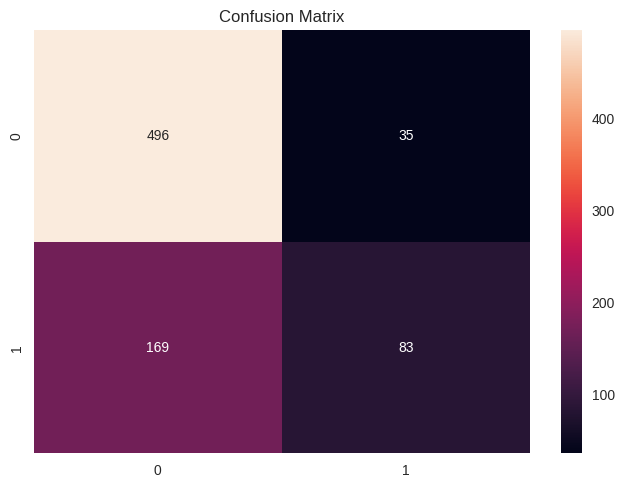

In [43]:
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

**10. Evaluation Rationale (Markdown Section)**

## Evaluation Metric

Accuracy was selected as the primary evaluation metric because this is a binary classification problem and the dataset shows relatively balanced class distribution.

Accuracy measures the proportion of correctly predicted instances out of total predictions.

For future improvements, Precision, Recall, and F1-score may be considered depending on business priorities (e.g., minimizing false negatives).